In [1]:
import numpy as np
from scipy import stats
import scipy
import matplotlib.pyplot as plt
import pandas as pd

## Chapter 6

In [2]:
# E 6.01: sR2 the witin-treatment mean squares
a601 = np.array([[1,3,5,np.nan],[9,5,5,5],[6,6,3,np.nan],[3,3,0,6],[14,10,18,np.nan]]).T
a601

array([[ 1.,  9.,  6.,  3., 14.],
       [ 3.,  5.,  6.,  3., 10.],
       [ 5.,  5.,  3.,  0., 18.],
       [nan,  5., nan,  6., nan]])

In [3]:
# within treatment sum squares
SR_601 = (np.nanvar(a601, axis=0, ddof=1) * (np.array([3,4,3,4,3])-1)).sum()
# within treatment mean squares
sR2_601 = SR_601 / (np.array([3,4,3,4,3]).sum() - 5)
SR_601, sR2_601

(np.float64(76.0), np.float64(6.333333333333333))

In [4]:
# E 6.02: ST2 the btw treatment sum squares
ST_601 = (((np.nanmean(a601,axis=0) - np.nanmean(a601))**2)*np.array([3,4,3,4,3])).sum()
# sT2 the btw treatment mean squares
sT2_601 = ST_601 / 4
ST_601, sT2_601

(np.float64(258.0), np.float64(64.5))

In [5]:
# E 6.03 build an analysis of variance table
# Total sum of squares of deviations from the grand average
SD_601 = SR_601 + ST_601
# total mean squares
sD2_601 = SD_601 / (np.array([3,4,3,4,3]).sum() - 5 + 4)
SD_601, sD2_601

(np.float64(334.0), np.float64(20.875))

In [6]:
# or
SD_601_2 = np.nansum(a601 ** 2) - 17 * np.nanmean(a601) ** 2

In [7]:
# E 6.04: Calculate SA and S
# SA: the sum of squares due to the grand average which is called the correction for the average or the correction factor
SA_601 = 17 * np.nanmean(a601) ** 2
SA_601

np.float64(612.0)

In [8]:
# or 
SA_601 = (np.nansum(a601))**2 / 17
SA_601

np.float64(612.0)

In [9]:
# SD: the total sum of squares o deviations from the grand average
# SD = ST + SR or the following
SD_601 = np.nansum((a601 - np.nanmean(a601))**2)
SD_601

np.float64(334.0)

In [10]:
# E 6.05: t test vs f test

# t test
mu605_s = 64
mu605 = 63
sR2_605 = 5.6 # within treatment mean of squares with degree of freedom of 20 from 24 samples in total
t605 = (mu605_s - mu605)/np.sqrt(sR2_605/24) 
t605

np.float64(2.0701966780270626)

In [11]:
# f test
f605 = 24*(mu605_s - mu605)/sR2_605
f605

4.285714285714286

In [12]:
t605**2, f605 

(np.float64(4.285714285714286), 4.285714285714286)

In [13]:
# E 6.06
# Y observations
y606 = a601
Y606 = np.nansum(y606 ** 2)
y606, Y606

(array([[ 1.,  9.,  6.,  3., 14.],
        [ 3.,  5.,  6.,  3., 10.],
        [ 5.,  5.,  3.,  0., 18.],
        [nan,  5., nan,  6., nan]]),
 np.float64(946.0))

In [14]:
# grand averages
a606 = np.full_like(y606, np.nanmean(y606))
a606[3,0], a606[3,2], a606[3,4] = np.nan, np.nan, np.nan
A606 = np.nansum(a606**2)
a606, A606

(array([[ 6.,  6.,  6.,  6.,  6.],
        [ 6.,  6.,  6.,  6.,  6.],
        [ 6.,  6.,  6.,  6.,  6.],
        [nan,  6., nan,  6., nan]]),
 np.float64(612.0))

In [15]:
# btw treatment deviations
t606 = np.tile(np.nanmean(y606, axis=0), (4,1)) - a606
# t606[3,0], t606[3,2], t606[3,4] = np.nan, np.nan, np.nan
T606 = np.nansum(t606**2)
t606, T606

(array([[-3.,  0., -1., -3.,  8.],
        [-3.,  0., -1., -3.,  8.],
        [-3.,  0., -1., -3.,  8.],
        [nan,  0., nan, -3., nan]]),
 np.float64(258.0))

In [16]:
# residuals (within treatment deviations)
r606 = y606 - np.tile(np.nanmean(y606, axis=0), (4,1))
R606 = np.nansum(r606**2)
r606, R606

(array([[-2.,  3.,  1.,  0.,  0.],
        [ 0., -1.,  1.,  0., -4.],
        [ 2., -1., -2., -3.,  4.],
        [nan, -1., nan,  3., nan]]),
 np.float64(76.0))

([<matplotlib.axis.XTick at 0x262807bc6e0>,
 [Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7'),
  Text(8.0, 0, '8'),
  Text(9.0, 0, '9'),
  Text(10.0, 0, '10'),
  Text(11.0, 0, '11'),
  Text(12.0, 0, '12'),
  Text(13.0, 0, '13'),
  Text(14.0, 0, '14'),
  Text(15.0, 0, '15'),
  Text(16.0, 0, '16'),
  Text(17.0, 0, '17'),
  Text(18.0, 0, '18'),
  Text(19.0, 0, '19'),
  Text(20.0, 0, '20')])

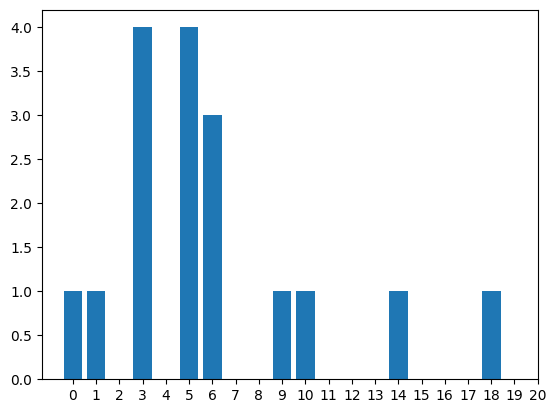

In [17]:
# E 6.07
plt.bar(np.unique(y606.ravel(), return_counts=True)[0], np.unique(y606.ravel(), return_counts=True)[1])
plt.xticks(np.linspace(0,20,21))

In [18]:
def dotplot(data):
    fig,ax = plt.subplots()
    counts = {}
    for i in data:
        counts[i] = counts.get(i, 0) + 1
        plt.plot(i, counts[i], 'bo', markersize=10)
        # plt.xticks(np.linspace(0,20,21))
    return fig, ax

(<Figure size 640x480 with 1 Axes>, <Axes: >)

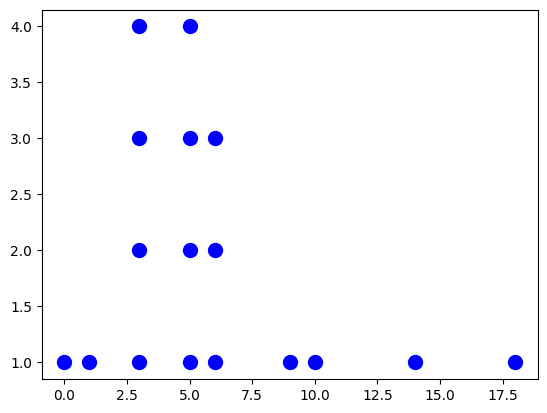

In [19]:
dotplot(y606.ravel())

(<Figure size 640x480 with 1 Axes>, <Axes: >)

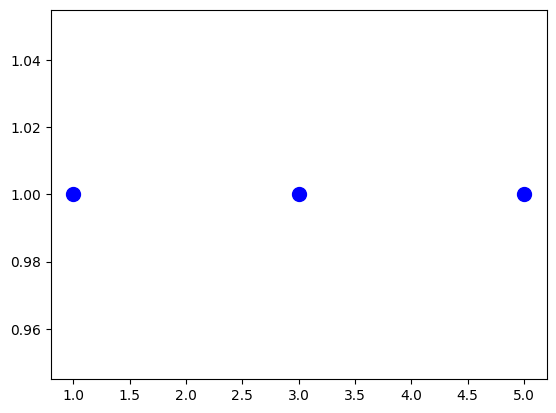

In [20]:
dotplot(y606[:,0])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

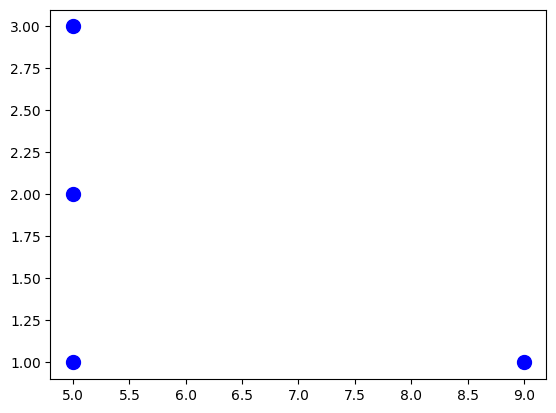

In [21]:
dotplot(y606[:,1])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

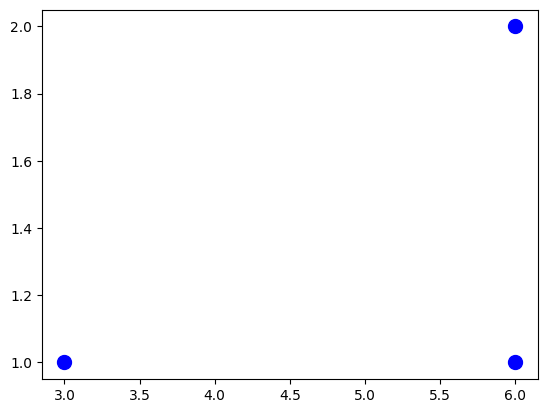

In [22]:
dotplot(y606[:,2])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

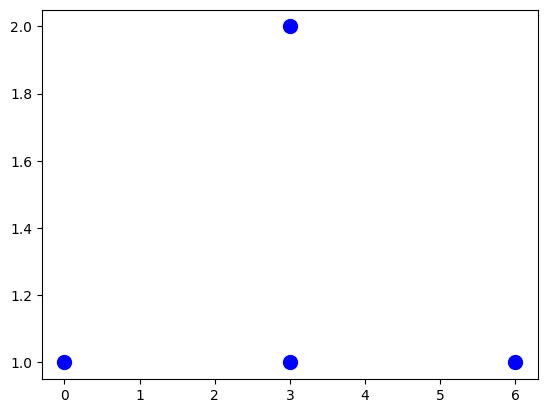

In [23]:
dotplot(y606[:,3])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

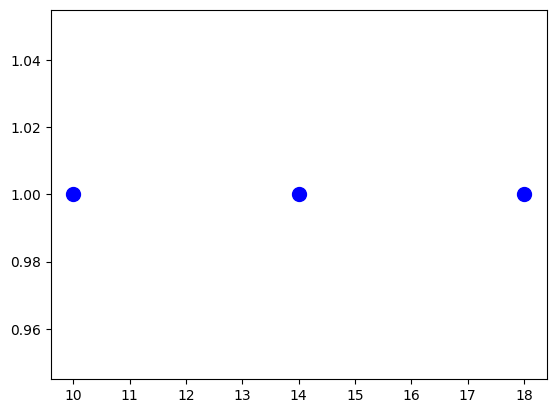

In [24]:
dotplot(y606[:,4])

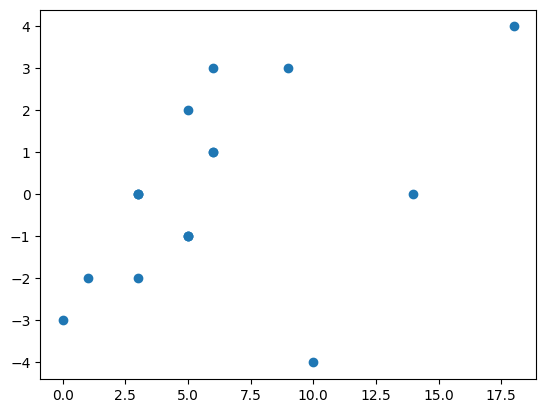

In [25]:
plt.scatter(y606.ravel(), r606.ravel())

In [26]:
# E 6.08
# null hypothesis: all treatment means are equal
sT2_601 / sR2_601

np.float64(10.18421052631579)

In [27]:
# assumptions: normal distribution of residuals or randomization of the tests within each treatment
# the result is significant at 0.00078 level. null hypothesis rejected.
stats.f.sf(sT2_601/sR2_601, dfn=4, dfd=12)

np.float64(0.0007821245265581024)

In [28]:
# E 6.09
# scale factor 
sR2_601, np.sqrt(sR2_601/(17/5))

(np.float64(6.333333333333333), np.float64(1.3648242004152826))

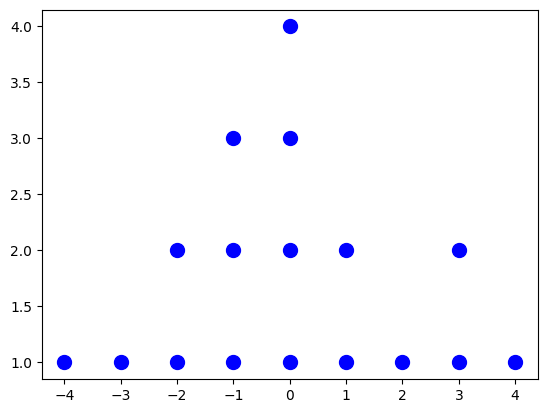

In [29]:
fig609, ax609 = dotplot(r606.ravel())

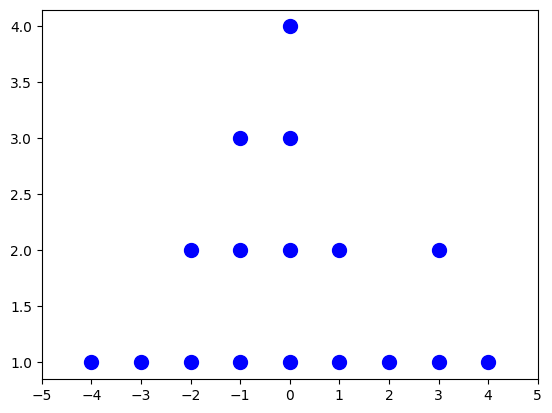

In [30]:
ax609.set_xlim(-5,5)
ax609.set_xticks(np.linspace(-5,5,11))
fig609

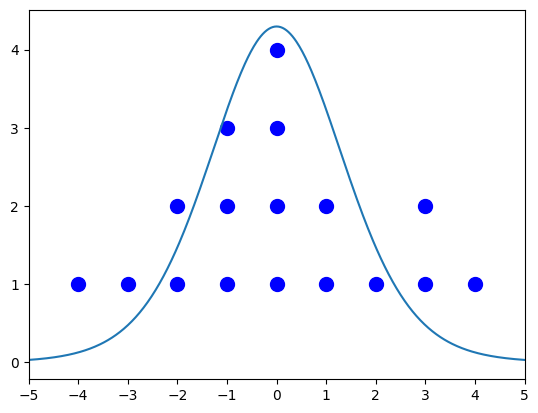

In [31]:
xs609 = np.linspace(-10,10,1001)
ts609 = np.array([])
for i in xs609:
    ts609 = np.append(ts609, 15* stats.t.pdf(i,df=12,scale=np.sqrt(sR2_601/(17/5))))
ax609.plot(xs609, ts609)
fig609

## Chapter 7

In [32]:
# E 7.01 create analysis of variance table
tr701a=3
bl701a=2
# observations
a701a = np.array([7,36,2,13,44,18]).reshape(bl701a,tr701a)
a701a, (a701a**2).sum(), a701a.shape[0]*a701a.shape[1]

(array([[ 7, 36,  2],
        [13, 44, 18]]),
 np.int64(3778),
 6)

In [33]:
# grand average
a701aa = np.full_like(a701a, a701a.mean())
a701aa, (a701aa**2).sum(), 1

(array([[20, 20, 20],
        [20, 20, 20]]),
 np.int64(2400),
 1)

In [34]:
# btw treatment deviations
t701a = np.tile(a701a.mean(axis=0), (bl701a,1)) - a701a.mean()
t701a, (t701a**2).sum(), tr701a-1

(array([[-10.,  20., -10.],
        [-10.,  20., -10.]]),
 np.float64(1200.0),
 2)

In [35]:
# btw block deviations
b701a = np.tile(a701a.mean(axis=1, keepdims=True), (1, tr701a)) - a701a.mean()
b701a, (b701a**2).sum(), bl701a-1

(array([[-5., -5., -5.],
        [ 5.,  5.,  5.]]),
 np.float64(150.0),
 1)

In [36]:
r701a = a701a - np.tile(a701a.mean(axis=0), (bl701a,1)) - np.tile(a701a.mean(axis=1, keepdims=True), (1, tr701a)) + a701a.mean()
r701a, (r701a**2).sum(), (a701a.shape[0]-1)*(a701a.shape[1]-1)

(array([[ 2.,  1., -3.],
        [-2., -1.,  3.]]),
 np.float64(28.0),
 2)

In [37]:
#b
tr701b = 3
bl701b = 4
a701b = np.array([6.5,7.4,7.4,6.8,7.3,6.9,6.4,7.2,8.,6.7,6.9,6.5]).reshape(bl701b, tr701b)
a701b, (a701b**2).sum(), a701b.shape[0]*a701b.shape[1]

(array([[6.5, 7.4, 7.4],
        [6.8, 7.3, 6.9],
        [6.4, 7.2, 8. ],
        [6.7, 6.9, 6.5]]),
 np.float64(590.46),
 12)

In [38]:
# grand average
a701ba = np.full_like(a701b, a701b.mean())
a701ba, (a701ba**2).sum(), 1

(array([[7., 7., 7.],
        [7., 7., 7.],
        [7., 7., 7.],
        [7., 7., 7.]]),
 np.float64(588.0000000000001),
 1)

In [39]:
# btw treatment deviations
a701bt = np.tile(a701b.mean(axis=0), (bl701b,1)) - a701b.mean()
a701bt, (a701bt**2).sum(), tr701b - 1

(array([[-0.4,  0.2,  0.2],
        [-0.4,  0.2,  0.2],
        [-0.4,  0.2,  0.2],
        [-0.4,  0.2,  0.2]]),
 np.float64(0.9599999999999974),
 2)

In [40]:
# btw block deviations
a701bb = np.tile(a701b.mean(axis=1, keepdims=True), (1, tr701b)) - a701b.mean()
a701bb, (a701bb**2).sum(), bl701b-1

(array([[ 1.0000000e-01,  1.0000000e-01,  1.0000000e-01],
        [-8.8817842e-16, -8.8817842e-16, -8.8817842e-16],
        [ 2.0000000e-01,  2.0000000e-01,  2.0000000e-01],
        [-3.0000000e-01, -3.0000000e-01, -3.0000000e-01]]),
 np.float64(0.4200000000000002),
 3)

In [41]:
# residuals
a701br = a701b - np.tile(a701b.mean(axis=0), (bl701b,1)) - np.tile(a701b.mean(axis=1, keepdims=True), (1, tr701b)) + a701b.mean()
a701br, (a701br**2).sum(), (a701b.shape[0]-1)*(a701b.shape[1]-1)

(array([[-2.00000000e-01,  1.00000000e-01,  1.00000000e-01],
        [ 2.00000000e-01,  1.00000000e-01, -3.00000000e-01],
        [-4.00000000e-01, -2.00000000e-01,  6.00000000e-01],
        [ 4.00000000e-01,  1.77635684e-15, -4.00000000e-01]]),
 np.float64(1.0799999999999996),
 6)

In [42]:
# E 7.03 Show R dot A as an example
A703 = np.ones((5,4)) * 86
A703

array([[86., 86., 86., 86.],
       [86., 86., 86., 86.],
       [86., 86., 86., 86.],
       [86., 86., 86., 86.],
       [86., 86., 86., 86.]])

In [43]:
R703 = np.array([-1,-3,2,2,3,-5,6,-4,-2,3,-1,0,1,5,-2,-4,-1,0,-5,6]).reshape(5,4)
R703

array([[-1, -3,  2,  2],
       [ 3, -5,  6, -4],
       [-2,  3, -1,  0],
       [ 1,  5, -2, -4],
       [-1,  0, -5,  6]])

In [44]:
A703.flatten().dot(R703.flatten())

np.float64(0.0)

In [45]:
# E 7.04
a701aa.flatten().dot(t701a.flatten()) # E 7.01a

np.float64(0.0)

In [46]:
a701bt.flatten().dot(a701bb.flatten()) # E 7.01b

np.float64(-1.443289932012653e-17)

In [47]:
# E 7.05
# E 7.01a
# residual
r701a

array([[ 2.,  1., -3.],
       [-2., -1.,  3.]])

In [48]:
a701a.mean(axis=0) - a701a.mean()
# deviation of treatment averages from grand average


array([-10.,  20., -10.])

In [49]:
a701a.mean(axis=1) - a701a.mean() # deviation of block averages from grand average

array([-5.,  5.])

In [50]:
# residual
a701br, a701b.mean(axis=0) - a701b.mean(), a701b.mean(axis=1) - a701b.mean()

(array([[-2.00000000e-01,  1.00000000e-01,  1.00000000e-01],
        [ 2.00000000e-01,  1.00000000e-01, -3.00000000e-01],
        [-4.00000000e-01, -2.00000000e-01,  6.00000000e-01],
        [ 4.00000000e-01,  1.77635684e-15, -4.00000000e-01]]),
 array([-0.4,  0.2,  0.2]),
 array([ 1.0000000e-01, -8.8817842e-16,  2.0000000e-01, -3.0000000e-01]))

In [51]:
# E 7.06
# 7.01a
a701aa + (np.tile(a701a.mean(axis=0), (2,1)) - a701aa) + (np.tile(a701a.mean(axis=1, keepdims=True), (1,3)) - a701aa)

array([[ 5., 35.,  5.],
       [15., 45., 15.]])

In [52]:
# 7.01b
a701ba + (np.tile(a701b.mean(axis=0), (4,1)) - a701ba) + (np.tile(a701b.mean(axis=1, keepdims=True), (1,3)) - a701ba)

array([[6.7, 7.3, 7.3],
       [6.6, 7.2, 7.2],
       [6.8, 7.4, 7.4],
       [6.3, 6.9, 6.9]])

In [53]:
a701b

array([[6.5, 7.4, 7.4],
       [6.8, 7.3, 6.9],
       [6.4, 7.2, 8. ],
       [6.7, 6.9, 6.5]])

In [54]:
# Table 7.09
a_T709 = np.array([89,88,97,94,84,77,92,79,81,87,87,85,87,92,89,84,79,81,80,88]).reshape(5,4)
a_T709a = np.full_like(a_T709, a_T709.mean()) #grand average
a_T709b = np.tile(a_T709.mean(axis=1, keepdims=True), (1,4)) # block average
a_T709bd = np.tile(a_T709.mean(axis=1, keepdims=True), (1,4)) - a_T709a # block deviation
a_T709t = np.tile(a_T709.mean(axis=0, keepdims=True), (5,1)) # treatment average
a_T709td = np.tile(a_T709.mean(axis=0, keepdims=True), (5,1)) - a_T709a # treatment deviation
a_T709r = a_T709 - a_T709b - a_T709t + a_T709a

a_T709, a_T709a, a_T709bd, a_T709td, a_T709r

(array([[89, 88, 97, 94],
        [84, 77, 92, 79],
        [81, 87, 87, 85],
        [87, 92, 89, 84],
        [79, 81, 80, 88]]),
 array([[86, 86, 86, 86],
        [86, 86, 86, 86],
        [86, 86, 86, 86],
        [86, 86, 86, 86],
        [86, 86, 86, 86]]),
 array([[ 6.,  6.,  6.,  6.],
        [-3., -3., -3., -3.],
        [-1., -1., -1., -1.],
        [ 2.,  2.,  2.,  2.],
        [-4., -4., -4., -4.]]),
 array([[-2., -1.,  3.,  0.],
        [-2., -1.,  3.,  0.],
        [-2., -1.,  3.,  0.],
        [-2., -1.,  3.,  0.],
        [-2., -1.,  3.,  0.]]),
 array([[-1., -3.,  2.,  2.],
        [ 3., -5.,  6., -4.],
        [-2.,  3., -1.,  0.],
        [ 1.,  5., -2., -4.],
        [-1.,  0., -5.,  6.]]))

In [55]:
a_T709q = (a_T709 - a_T709r) ** 2
a_T709q

array([[8100., 8281., 9025., 8464.],
       [6561., 6724., 7396., 6889.],
       [6889., 7056., 7744., 7225.],
       [7396., 7569., 8281., 7744.],
       [6400., 6561., 7225., 6724.]])

In [56]:
# Table 7.09
a_T709qa = np.full_like(a_T709q, a_T709q.mean()) #grand average
a_T709qb = np.tile(a_T709q.mean(axis=1, keepdims=True), (1,4)) # block average
a_T709qbd = np.tile(a_T709q.mean(axis=1, keepdims=True), (1,4)) - a_T709qa # block deviation
a_T709qt = np.tile(a_T709q.mean(axis=0, keepdims=True), (5,1)) # treatment average
a_T709qtd = np.tile(a_T709q.mean(axis=0, keepdims=True), (5,1)) - a_T709qa # treatment deviation
a_T709qr = a_T709q - a_T709qb - a_T709qt + a_T709qa

a_T709q, a_T709qa, a_T709qbd, a_T709qtd, a_T709qr

(array([[8100., 8281., 9025., 8464.],
        [6561., 6724., 7396., 6889.],
        [6889., 7056., 7744., 7225.],
        [7396., 7569., 8281., 7744.],
        [6400., 6561., 7225., 6724.]]),
 array([[7412.7, 7412.7, 7412.7, 7412.7],
        [7412.7, 7412.7, 7412.7, 7412.7],
        [7412.7, 7412.7, 7412.7, 7412.7],
        [7412.7, 7412.7, 7412.7, 7412.7],
        [7412.7, 7412.7, 7412.7, 7412.7]]),
 array([[1054.8, 1054.8, 1054.8, 1054.8],
        [-520.2, -520.2, -520.2, -520.2],
        [-184.2, -184.2, -184.2, -184.2],
        [ 334.8,  334.8,  334.8,  334.8],
        [-685.2, -685.2, -685.2, -685.2]]),
 array([[-343.5, -174.5,  521.5,   -3.5],
        [-343.5, -174.5,  521.5,   -3.5],
        [-343.5, -174.5,  521.5,   -3.5],
        [-343.5, -174.5,  521.5,   -3.5],
        [-343.5, -174.5,  521.5,   -3.5]]),
 array([[-24., -12.,  36.,   0.],
        [ 12.,   6., -18.,   0.],
        [  4.,   2.,  -6.,   0.],
        [ -8.,  -4.,  12.,   0.],
        [ 16.,   8., -24.,   0.]]))

In [57]:
# P, Q, and Sna in table 7.9
a_T709r.flatten().dot(a_T709qr.flatten()), (a_T709qr**2).sum(), (a_T709r.flatten().dot(a_T709qr.flatten()))**2 / (a_T709qr**2).sum(), 


(np.float64(86.0), np.float64(3696.0), np.float64(2.0010822510822512))

In [58]:
# E 7.07
sum_sq_707a = {'btw blocks': (b701a**2).sum(), 'btw treatments': (t701a**2).sum(), 'residuals': (r701a**2).sum()}
dof_707a = {'btw blocks': a701a.shape[0]-1, 'btw treatments': a701a.shape[1]-1, 'residuals': (a701a.shape[0]-1) * (a701a.shape[1]-1)}
table_707a = np.concat((np.array(list(sum_sq_707a.values())), np.array(list(dof_707a.values())))).reshape(2,3).T
sum_sq_707a, dof_707a, table_707a

({'btw blocks': np.float64(150.0),
  'btw treatments': np.float64(1200.0),
  'residuals': np.float64(28.0)},
 {'btw blocks': 1, 'btw treatments': 2, 'residuals': 2},
 array([[1.5e+02, 1.0e+00],
        [1.2e+03, 2.0e+00],
        [2.8e+01, 2.0e+00]]))

In [59]:
table_707a = np.append(table_707a, table_707a[:,[0]] / table_707a[:,[1]], axis=1) # append mean square

In [60]:
table_707a = np.append(table_707a, table_707a[:,[2]] / table_707a[2,2], axis=1) # append the ratios

In [61]:
table_707a

array([[1.50000000e+02, 1.00000000e+00, 1.50000000e+02, 1.07142857e+01],
       [1.20000000e+03, 2.00000000e+00, 6.00000000e+02, 4.28571429e+01],
       [2.80000000e+01, 2.00000000e+00, 1.40000000e+01, 1.00000000e+00]])

In [62]:
stats.f.sf(10.7, dfn=1, dfd=2) # btw blocks

np.float64(0.08211128940411842)

In [63]:
stats.f.sf(42.8, dfn=2, dfd=2) # btw treatments

np.float64(0.022831050228310504)

In [64]:
a701a

array([[ 7, 36,  2],
       [13, 44, 18]])

In [65]:
# b
sum_sq_707b = np.array([(a701bb**2).sum(), (a701bt**2).sum(), (a701br**2).sum()])
df_707b = np.array([a701b.shape[0]-1, a701b.shape[1]-1, (a701b.shape[0]-1)*(a701b.shape[1]-1)])
sum_sq_707b, df_707b

(array([0.42, 0.96, 1.08]), array([3, 2, 6]))

In [66]:
mean_sq_707b = sum_sq_707b / df_707b
ratio_mean_sq_707b = mean_sq_707b / mean_sq_707b[2]
mean_sq_707b, ratio_mean_sq_707b

(array([0.14, 0.48, 0.18]), array([0.77777778, 2.66666667, 1.        ]))

In [67]:
table_707b = np.concat((sum_sq_707b, df_707b, mean_sq_707b, ratio_mean_sq_707b)).reshape(4,3).T
table_707b

array([[0.42      , 3.        , 0.14      , 0.77777778],
       [0.96      , 2.        , 0.48      , 2.66666667],
       [1.08      , 6.        , 0.18      , 1.        ]])

In [68]:
stats.f.sf(table_707b[0,3], dfn=3, dfd=6), stats.f.sf(table_707b[1,3], dfn=2, dfd=6) # f test for blocks and treatments both no significant difference

(np.float64(0.5478093519233282), np.float64(0.14838184408711627))

In [69]:
# E 7.08
a708 = np.array([0.31,0.45,0.46,0.43,0.82,1.1,0.88,0.72,0.43,0.45,0.63,0.76,0.45,0.71,0.66,0.63,
          0.36,0.29,0.4,0.23,0.92,0.61,0.49,1.24,0.44,0.35,0.31,0.4,0.56,1.02,0.71,0.38,
          0.22,0.21,0.18,0.23,0.30,0.37,0.38,0.29,0.23,0.25,0.24,0.22,0.30,0.36,0.31,0.33]).reshape(3,4,4) # the layer 3 poisons, the second layer 4 treatments, the third layer 4 animals
a708a = np.full_like(a708, a708.mean()) # grand average
df708 = np.prod(a708.shape) # degree of freedom of the original data
df708a = 1 # degree of freedom of the grand average 
a708, a708a, df708, df708a

(array([[[0.31, 0.45, 0.46, 0.43],
         [0.82, 1.1 , 0.88, 0.72],
         [0.43, 0.45, 0.63, 0.76],
         [0.45, 0.71, 0.66, 0.63]],
 
        [[0.36, 0.29, 0.4 , 0.23],
         [0.92, 0.61, 0.49, 1.24],
         [0.44, 0.35, 0.31, 0.4 ],
         [0.56, 1.02, 0.71, 0.38]],
 
        [[0.22, 0.21, 0.18, 0.23],
         [0.3 , 0.37, 0.38, 0.29],
         [0.23, 0.25, 0.24, 0.22],
         [0.3 , 0.36, 0.31, 0.33]]]),
 array([[[0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 0.47958333, 0.47958333]],
 
        [[0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 0.47958333, 0.47958333]],
 
        [[0.47958333, 0.47958333, 0.47958333, 0.47958333],
         [0.47958333, 0.47958333, 

In [70]:
a708pa = np.tile(a708.mean(axis=(1,2), keepdims=True), (1,4,4)) # poison average
a708pd = a708pa - a708.mean() # poison deviation
df708p = a708.shape[0] - 1

a708ta = np.tile(a708.mean(axis=(0,2), keepdims=True), (3,1,4)) # treatment average
a708td = a708ta - a708.mean() # treatment deviation
df708t = a708.shape[1] - 1


a708ia = np.tile(a708.mean(axis=2, keepdims=True), (1,1,4)) # interaction average on 4 animals
a708id = a708ia - a708pa - a708ta + a708.mean() # poison and treatment interaction deviation
df708i = np.prod(np.array(a708.shape[:2]) - 1)

a708r = a708 - a708ia # error
df708r = a708.shape[0]*a708.shape[1]*(a708.shape[2]-1) 
# a708p, a708t, a708i, a708r


In [71]:
# the sum of deviation squares of poison 
SP708 = (a708pd**2).sum()
ST708 = (a708td**2).sum()
SPTI708 = (a708id**2).sum()
SE708 = (a708r**2).sum()
SP708, ST708, SPTI708, SE708

(np.float64(1.0357791666666667),
 np.float64(0.9223083333333332),
 np.float64(0.24890416666666668),
 np.float64(0.801))

In [72]:
STotal708 = SP708 + ST708 + SPTI708 + SE708
dfTotal708 = df708p + df708t + df708i + df708r
STotal708, dfTotal708

(np.float64(3.007991666666667), np.int64(47))

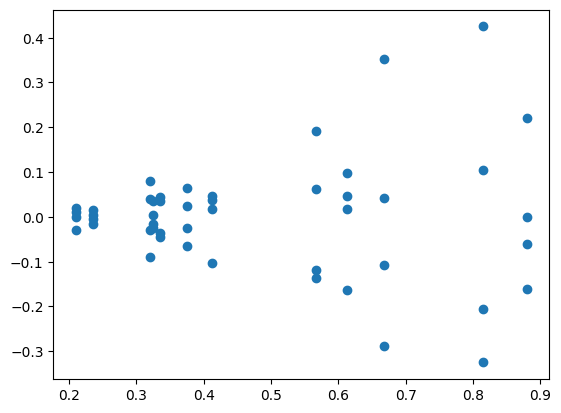

In [73]:
plt.scatter(a708ia.flatten(), a708r.flatten()) # Figure 7.6a

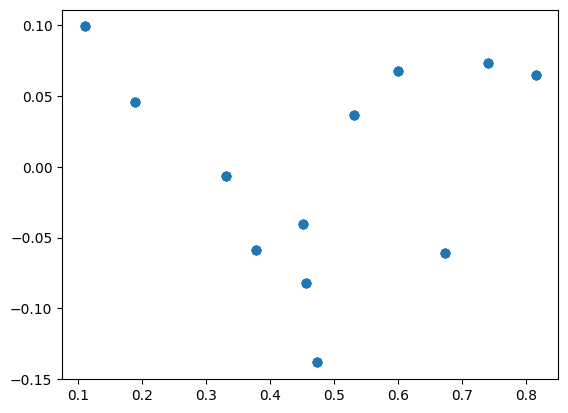

In [74]:
plt.scatter((a708pa + a708ta - a708a), a708ia - (a708pa + a708ta - a708a)) # Figure 7.6b

In [75]:
# Figure 7.8
y_bar_F708 = a708.mean(axis=(2))
s_F708 = np.std(a708, axis=2, ddof=1)
y_bar_F708, s_F708

(array([[0.4125, 0.88  , 0.5675, 0.6125],
        [0.32  , 0.815 , 0.375 , 0.6675],
        [0.21  , 0.335 , 0.235 , 0.325 ]]),
 array([[0.06946222, 0.16083117, 0.15671099, 0.11324752],
        [0.07527727, 0.33630343, 0.05686241, 0.27097048],
        [0.02160247, 0.04654747, 0.01290994, 0.02645751]]))

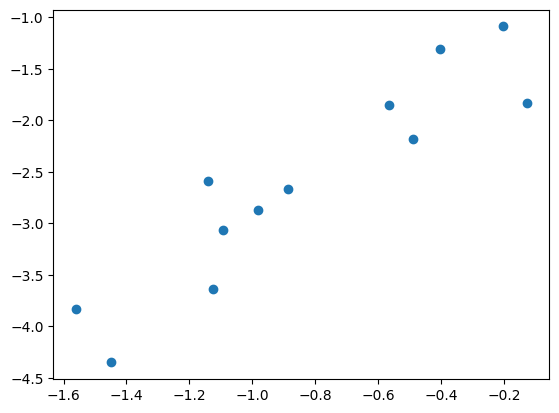

In [76]:
plt.scatter(np.log(y_bar_F708.flatten()), np.log(s_F708.flatten()))


In [77]:
np.polyfit(np.log(y_bar_F708.flatten()), np.log(s_F708.flatten()), deg=1) # slope is close to 2 (alpha), so lamda for transformation is 1-alpha=-1, meaning reciprocal transformation

array([ 1.97598342, -0.95409041])

In [78]:
yti_bar_T714 = y_bar_F708

In [79]:
yti_hat_T714 = (a708ta + a708pa - a708a).mean(axis=2)
yti_hat_T714

array([[0.45270833, 0.81520833, 0.53104167, 0.67354167],
       [0.37895833, 0.74145833, 0.45729167, 0.59979167],
       [0.11083333, 0.47333333, 0.18916667, 0.33166667]])

In [80]:
yti_bar_T714 - yti_hat_T714

array([[-0.04020833,  0.06479167,  0.03645833, -0.06104167],
       [-0.05895833,  0.07354167, -0.08229167,  0.06770833],
       [ 0.09916667, -0.13833333,  0.04583333, -0.00666667]])

In [81]:
qti_T714 = yti_hat_T714**2

In [82]:
qti_bar_T714 = np.tile(qti_T714.mean(axis=0), (3,1)) + np.tile(qti_T714.mean(axis=1, keepdims=True), (1,4)) - qti_T714.mean() # treatment average + poison average - grand average
qti_bar_T714

array([[ 2.50779036e-01,  6.09956120e-01,  3.06134592e-01,
         4.38303342e-01],
       [ 1.65044661e-01,  5.24221745e-01,  2.20400217e-01,
         3.52568967e-01],
       [-5.49854167e-02,  3.04191667e-01,  3.70138889e-04,
         1.32538889e-01]])

In [83]:
qti_T714 - qti_bar_T714

array([[-0.0458342 ,  0.05460851, -0.02412934,  0.01535503],
       [-0.02143524,  0.02553872, -0.01128455,  0.00718108],
       [ 0.06726944, -0.08014722,  0.03541389, -0.02253611]])

In [84]:
P_T714 = 4 * ((yti_bar_T714 - yti_hat_T714) * (qti_T714 - qti_bar_T714)).sum() # 4 means 4 animals
P_T714

np.float64(0.11060866319444451)

In [85]:
Q_T714 = 4 * ((qti_T714 - qti_bar_T714)**2).sum()
Q_T714

np.float64(0.07960897974247694)

In [86]:
Sna_T714 = P_T714**2 / Q_T714
Sna_T714, Sna_T714 / 1 # transformable interaction with a degree of freedom of 1, mean squares

(np.float64(0.15367960264329608), np.float64(0.15367960264329608))

In [87]:
SE708, SE708 / 36 #  sum of squares for error with the degree of freedom of 36

(np.float64(0.801), np.float64(0.022250000000000002))

In [88]:
SPTI708 # sum of squares for interaction with the degree of freedom of 6

np.float64(0.24890416666666668)

In [89]:
# sum of squares for interaction that is not covered in Sna_T714 
SPTI708 - Sna_T714, (SPTI708 - Sna_T714) / 5 # degree of freedom 6-1=5

(np.float64(0.0952245640233706), np.float64(0.01904491280467412))

In [90]:
# F scores
(Sna_T714 / 1) / (SE708 / 36)

np.float64(6.906948433406565)

In [91]:
stats.f.sf((Sna_T714 / 1) / (SE708 / 36), dfn=1, dfd=36)

np.float64(0.012541399600422005)

In [92]:
# Table 7.15
a_T715 = 1 / a708
a_T715

array([[[3.22580645, 2.22222222, 2.17391304, 2.3255814 ],
        [1.2195122 , 0.90909091, 1.13636364, 1.38888889],
        [2.3255814 , 2.22222222, 1.58730159, 1.31578947],
        [2.22222222, 1.4084507 , 1.51515152, 1.58730159]],

       [[2.77777778, 3.44827586, 2.5       , 4.34782609],
        [1.08695652, 1.63934426, 2.04081633, 0.80645161],
        [2.27272727, 2.85714286, 3.22580645, 2.5       ],
        [1.78571429, 0.98039216, 1.4084507 , 2.63157895]],

       [[4.54545455, 4.76190476, 5.55555556, 4.34782609],
        [3.33333333, 2.7027027 , 2.63157895, 3.44827586],
        [4.34782609, 4.        , 4.16666667, 4.54545455],
        [3.33333333, 2.77777778, 3.22580645, 3.03030303]]])

In [93]:
a_T715a = np.full_like(a_T715, a_T715.mean())
a_T715a

array([[[2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292]],

       [[2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292]],

       [[2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292],
        [2.62184292, 2.62184292, 2.62184292, 2.62184292]]])

In [94]:
a_T715_pa = np.tile(a_T715.mean(axis=(1,2), keepdims=True), (1,4,4))
a_T715_pd = a_T715_pa - a_T715a
a_T715_pa, a_T715_pd

(array([[[1.79908747, 1.79908747, 1.79908747, 1.79908747],
         [1.79908747, 1.79908747, 1.79908747, 1.79908747],
         [1.79908747, 1.79908747, 1.79908747, 1.79908747],
         [1.79908747, 1.79908747, 1.79908747, 1.79908747]],
 
        [[2.26932882, 2.26932882, 2.26932882, 2.26932882],
         [2.26932882, 2.26932882, 2.26932882, 2.26932882],
         [2.26932882, 2.26932882, 2.26932882, 2.26932882],
         [2.26932882, 2.26932882, 2.26932882, 2.26932882]],
 
        [[3.79711248, 3.79711248, 3.79711248, 3.79711248],
         [3.79711248, 3.79711248, 3.79711248, 3.79711248],
         [3.79711248, 3.79711248, 3.79711248, 3.79711248],
         [3.79711248, 3.79711248, 3.79711248, 3.79711248]]]),
 array([[[-0.82275546, -0.82275546, -0.82275546, -0.82275546],
         [-0.82275546, -0.82275546, -0.82275546, -0.82275546],
         [-0.82275546, -0.82275546, -0.82275546, -0.82275546],
         [-0.82275546, -0.82275546, -0.82275546, -0.82275546]],
 
        [[-0.3525141 , -0.35

In [95]:
a_T715_ta = np.tile(a_T715.mean(axis=(0,2), keepdims=True), (3,1,4))
a_T715_td = a_T715_ta - a_T715a
a_T715_ta, a_T715_td

(array([[[3.51934532, 3.51934532, 3.51934532, 3.51934532],
         [1.86194293, 1.86194293, 1.86194293, 1.86194293],
         [2.94720988, 2.94720988, 2.94720988, 2.94720988],
         [2.15887356, 2.15887356, 2.15887356, 2.15887356]],
 
        [[3.51934532, 3.51934532, 3.51934532, 3.51934532],
         [1.86194293, 1.86194293, 1.86194293, 1.86194293],
         [2.94720988, 2.94720988, 2.94720988, 2.94720988],
         [2.15887356, 2.15887356, 2.15887356, 2.15887356]],
 
        [[3.51934532, 3.51934532, 3.51934532, 3.51934532],
         [1.86194293, 1.86194293, 1.86194293, 1.86194293],
         [2.94720988, 2.94720988, 2.94720988, 2.94720988],
         [2.15887356, 2.15887356, 2.15887356, 2.15887356]]]),
 array([[[ 0.89750239,  0.89750239,  0.89750239,  0.89750239],
         [-0.75989999, -0.75989999, -0.75989999, -0.75989999],
         [ 0.32536696,  0.32536696,  0.32536696,  0.32536696],
         [-0.46296936, -0.46296936, -0.46296936, -0.46296936]],
 
        [[ 0.89750239,  0.89

In [96]:
a_T715_pta = np.tile(a_T715.mean(axis=(2), keepdims=True), (1,1,4))
a_T715_ptd = a_T715_pta - a_T715_pa - a_T715_ta + a_T715a
a_T715_pta, a_T715_ptd

(array([[[2.48688078, 2.48688078, 2.48688078, 2.48688078],
         [1.16346391, 1.16346391, 1.16346391, 1.16346391],
         [1.86272367, 1.86272367, 1.86272367, 1.86272367],
         [1.68328151, 1.68328151, 1.68328151, 1.68328151]],
 
        [[3.26846993, 3.26846993, 3.26846993, 3.26846993],
         [1.39339218, 1.39339218, 1.39339218, 1.39339218],
         [2.71391915, 2.71391915, 2.71391915, 2.71391915],
         [1.70153402, 1.70153402, 1.70153402, 1.70153402]],
 
        [[4.80268524, 4.80268524, 4.80268524, 4.80268524],
         [3.02897271, 3.02897271, 3.02897271, 3.02897271],
         [4.26498682, 4.26498682, 4.26498682, 4.26498682],
         [3.09180515, 3.09180515, 3.09180515, 3.09180515]]]),
 array([[[-0.20970908, -0.20970908, -0.20970908, -0.20970908],
         [ 0.12427643,  0.12427643,  0.12427643,  0.12427643],
         [-0.26173075, -0.26173075, -0.26173075, -0.26173075],
         [ 0.3471634 ,  0.3471634 ,  0.3471634 ,  0.3471634 ]],
 
        [[ 0.10163872,  0.10

In [97]:
a_T715_r = a_T715 - a_T715_pta # within group deviations total 3*4=12 groups
a_T715_r

array([[[ 0.73892567, -0.26465856, -0.31296773, -0.16129938],
        [ 0.05604829, -0.254373  , -0.02710027,  0.22542498],
        [ 0.46285773,  0.35949855, -0.27542208, -0.5469342 ],
        [ 0.53894071, -0.2748308 , -0.16812999, -0.09597992]],

       [[-0.49069215,  0.17980593, -0.76846993,  1.07935616],
        [-0.30643566,  0.24595208,  0.64742415, -0.58694057],
        [-0.44119187,  0.14322371,  0.51188731, -0.21391915],
        [ 0.08418026, -0.72114187, -0.29308332,  0.93004492]],

       [[-0.25723069, -0.04078048,  0.75287032, -0.45485915],
        [ 0.30436062, -0.32627001, -0.39739376,  0.41930315],
        [ 0.08283926, -0.26498682, -0.09832016,  0.28046772],
        [ 0.24152819, -0.31402737,  0.1340013 , -0.06150212]]])

In [98]:
SP_T715 = (a_T715_pd ** 2).sum() # sum squares
sp_T715 = SP_T715 / 2 # 3 poisons - 1, mean squares
SP_T715, sp_T715

(np.float64(34.919220287059254), np.float64(17.459610143529627))

In [99]:
ST_T715 = (a_T715_td ** 2).sum()
st_T715 = ST_T715 / 3 # 4 treatments - 1
ST_T715, st_T715

(np.float64(20.437953930921573), np.float64(6.812651310307191))

In [100]:
SPT_T715 = (a_T715_ptd ** 2).sum()
spt_T715 = SPT_T715 / 6 # degree of freedom 2 * 3 = 6
SPT_T715, spt_T715

(np.float64(1.5529144276140334), np.float64(0.25881907126900555))

In [101]:
SE_T715 = (a_T715_r ** 2).sum()
se_T715 = SE_T715 / 35 # total 12 groups, each group with 3 freedom.
# However, the fact that the data have been used to choose the transformation is approximately allowed for (see Box and Cox 1964)
# by reducing the number of degrees of freedom in the within group mean square by unity (from 36 to 35)
SE_T715, se_T715


(np.float64(8.647505971115944), np.float64(0.24707159917474125))

In [102]:
# now check transformable interactions
q_T715 = (a_T715_pa + a_T715_ta - a_T715a) ** 2
q_T715

array([[[ 7.27159687,  7.27159687,  7.27159687,  7.27159687],
        [ 1.07991061,  1.07991061,  1.07991061,  1.07991061],
        [ 4.5133066 ,  4.5133066 ,  4.5133066 ,  4.5133066 ],
        [ 1.78521159,  1.78521159,  1.78521159,  1.78521159]],

       [[10.02881994, 10.02881994, 10.02881994, 10.02881994],
        [ 2.2783754 ,  2.2783754 ,  2.2783754 ,  2.2783754 ],
        [ 6.73244618,  6.73244618,  6.73244618,  6.73244618],
        [ 3.26293449,  3.26293449,  3.26293449,  3.26293449]],

       [[22.03940882, 22.03940882, 22.03940882, 22.03940882],
        [ 9.22465972,  9.22465972,  9.22465972,  9.22465972],
        [16.99483672, 16.99483672, 16.99483672, 16.99483672],
        [11.11651033, 11.11651033, 11.11651033, 11.11651033]]])

In [103]:
q_T715_pa = np.tile(q_T715.mean(axis=(1,2), keepdims=True), (1,4,4))
q_T715_pd = q_T715_pa - q_T715
q_T715_pa, q_T715_pd

(array([[[ 3.66250642,  3.66250642,  3.66250642,  3.66250642],
         [ 3.66250642,  3.66250642,  3.66250642,  3.66250642],
         [ 3.66250642,  3.66250642,  3.66250642,  3.66250642],
         [ 3.66250642,  3.66250642,  3.66250642,  3.66250642]],
 
        [[ 5.575644  ,  5.575644  ,  5.575644  ,  5.575644  ],
         [ 5.575644  ,  5.575644  ,  5.575644  ,  5.575644  ],
         [ 5.575644  ,  5.575644  ,  5.575644  ,  5.575644  ],
         [ 5.575644  ,  5.575644  ,  5.575644  ,  5.575644  ]],
 
        [[14.8438539 , 14.8438539 , 14.8438539 , 14.8438539 ],
         [14.8438539 , 14.8438539 , 14.8438539 , 14.8438539 ],
         [14.8438539 , 14.8438539 , 14.8438539 , 14.8438539 ],
         [14.8438539 , 14.8438539 , 14.8438539 , 14.8438539 ]]]),
 array([[[-3.60909045, -3.60909045, -3.60909045, -3.60909045],
         [ 2.5825958 ,  2.5825958 ,  2.5825958 ,  2.5825958 ],
         [-0.85080018, -0.85080018, -0.85080018, -0.85080018],
         [ 1.87729483,  1.87729483,  1.8772948

In [104]:
q_T715_ta = np.tile(q_T715.mean(axis=(0,2), keepdims=True), (3,1,4))
q_T715_td = q_T715_ta - q_T715
q_T715_ta, q_T715_td

(array([[[13.11327521, 13.11327521, 13.11327521, 13.11327521],
         [ 4.19431524,  4.19431524,  4.19431524,  4.19431524],
         [ 9.41352983,  9.41352983,  9.41352983,  9.41352983],
         [ 5.3882188 ,  5.3882188 ,  5.3882188 ,  5.3882188 ]],
 
        [[13.11327521, 13.11327521, 13.11327521, 13.11327521],
         [ 4.19431524,  4.19431524,  4.19431524,  4.19431524],
         [ 9.41352983,  9.41352983,  9.41352983,  9.41352983],
         [ 5.3882188 ,  5.3882188 ,  5.3882188 ,  5.3882188 ]],
 
        [[13.11327521, 13.11327521, 13.11327521, 13.11327521],
         [ 4.19431524,  4.19431524,  4.19431524,  4.19431524],
         [ 9.41352983,  9.41352983,  9.41352983,  9.41352983],
         [ 5.3882188 ,  5.3882188 ,  5.3882188 ,  5.3882188 ]]]),
 array([[[ 5.84167834,  5.84167834,  5.84167834,  5.84167834],
         [ 3.11440463,  3.11440463,  3.11440463,  3.11440463],
         [ 4.90022324,  4.90022324,  4.90022324,  4.90022324],
         [ 3.60300722,  3.60300722,  3.6030072

In [105]:
q_T715_pta = np.tile(q_T715.mean(axis=2, keepdims=True), (1,1,4))
q_T715_pta

array([[[ 7.27159687,  7.27159687,  7.27159687,  7.27159687],
        [ 1.07991061,  1.07991061,  1.07991061,  1.07991061],
        [ 4.5133066 ,  4.5133066 ,  4.5133066 ,  4.5133066 ],
        [ 1.78521159,  1.78521159,  1.78521159,  1.78521159]],

       [[10.02881994, 10.02881994, 10.02881994, 10.02881994],
        [ 2.2783754 ,  2.2783754 ,  2.2783754 ,  2.2783754 ],
        [ 6.73244618,  6.73244618,  6.73244618,  6.73244618],
        [ 3.26293449,  3.26293449,  3.26293449,  3.26293449]],

       [[22.03940882, 22.03940882, 22.03940882, 22.03940882],
        [ 9.22465972,  9.22465972,  9.22465972,  9.22465972],
        [16.99483672, 16.99483672, 16.99483672, 16.99483672],
        [11.11651033, 11.11651033, 11.11651033, 11.11651033]]])

In [106]:
q_T715_pt_hat = q_T715_pa + q_T715_ta - q_T715.mean()
q_T715, q_T715_pt_hat

(array([[[ 7.27159687,  7.27159687,  7.27159687,  7.27159687],
         [ 1.07991061,  1.07991061,  1.07991061,  1.07991061],
         [ 4.5133066 ,  4.5133066 ,  4.5133066 ,  4.5133066 ],
         [ 1.78521159,  1.78521159,  1.78521159,  1.78521159]],
 
        [[10.02881994, 10.02881994, 10.02881994, 10.02881994],
         [ 2.2783754 ,  2.2783754 ,  2.2783754 ,  2.2783754 ],
         [ 6.73244618,  6.73244618,  6.73244618,  6.73244618],
         [ 3.26293449,  3.26293449,  3.26293449,  3.26293449]],
 
        [[22.03940882, 22.03940882, 22.03940882, 22.03940882],
         [ 9.22465972,  9.22465972,  9.22465972,  9.22465972],
         [16.99483672, 16.99483672, 16.99483672, 16.99483672],
         [11.11651033, 11.11651033, 11.11651033, 11.11651033]]]),
 array([[[ 8.74844685,  8.74844685,  8.74844685,  8.74844685],
         [-0.17051311, -0.17051311, -0.17051311, -0.17051311],
         [ 5.04870148,  5.04870148,  5.04870148,  5.04870148],
         [ 1.02339045,  1.02339045,  1.0233904

In [107]:
a_T715_pt_hat = a_T715_ta + a_T715_pa - a_T715a
a_T715_pta, a_T715_pt_hat

(array([[[2.48688078, 2.48688078, 2.48688078, 2.48688078],
         [1.16346391, 1.16346391, 1.16346391, 1.16346391],
         [1.86272367, 1.86272367, 1.86272367, 1.86272367],
         [1.68328151, 1.68328151, 1.68328151, 1.68328151]],
 
        [[3.26846993, 3.26846993, 3.26846993, 3.26846993],
         [1.39339218, 1.39339218, 1.39339218, 1.39339218],
         [2.71391915, 2.71391915, 2.71391915, 2.71391915],
         [1.70153402, 1.70153402, 1.70153402, 1.70153402]],
 
        [[4.80268524, 4.80268524, 4.80268524, 4.80268524],
         [3.02897271, 3.02897271, 3.02897271, 3.02897271],
         [4.26498682, 4.26498682, 4.26498682, 4.26498682],
         [3.09180515, 3.09180515, 3.09180515, 3.09180515]]]),
 array([[[2.69658986, 2.69658986, 2.69658986, 2.69658986],
         [1.03918748, 1.03918748, 1.03918748, 1.03918748],
         [2.12445442, 2.12445442, 2.12445442, 2.12445442],
         [1.3361181 , 1.3361181 , 1.3361181 , 1.3361181 ]],
 
        [[3.16683121, 3.16683121, 3.16683121

In [108]:
P_T715 = ((a_T715_pta - a_T715_pt_hat) * (q_T715_pta - q_T715_pt_hat)).sum()
Q_T715 = ((q_T715_pta - q_T715_pt_hat)**2).sum()

Sna_T715 = P_T715**2 / Q_T715 #  sum of squares for transformable
sna_T715 = Sna_T715 / 1 # mean squares for transformable

P_T715, Q_T715, Sna_T715, sna_T715

(np.float64(5.188316925460324),
 np.float64(59.473117960884835),
 np.float64(0.4526184844844071),
 np.float64(0.4526184844844071))

In [109]:
# F scores for the transformable interaction form the transformed data
q_f_T715 = sna_T715 / se_T715
q_f_T715

np.float64(1.8319324681437503)

In [110]:
# significance
stats.f.sf(q_f_T715, dfn=1, dfd=35) # not significant transformable interaction effect

np.float64(0.18457657636290273)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

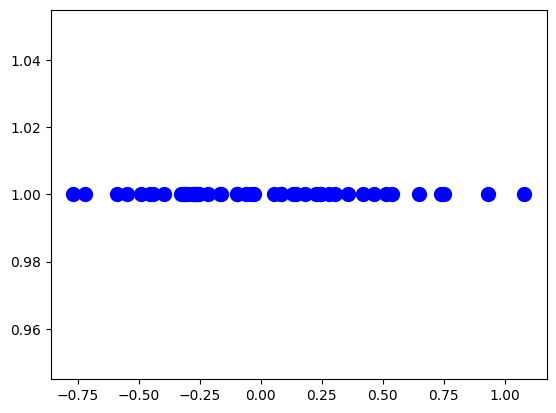

In [111]:
# E 7.09
# Plots of residuals
dotplot(a_T715_r.flatten())

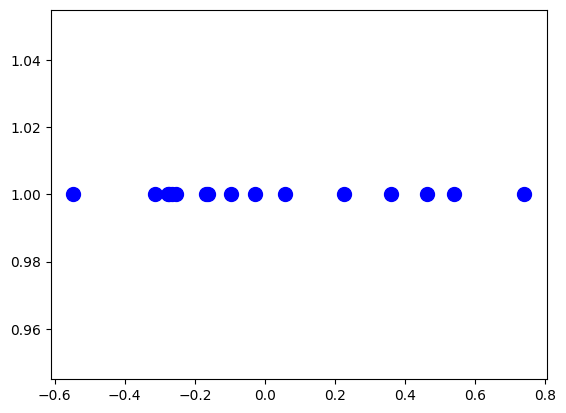

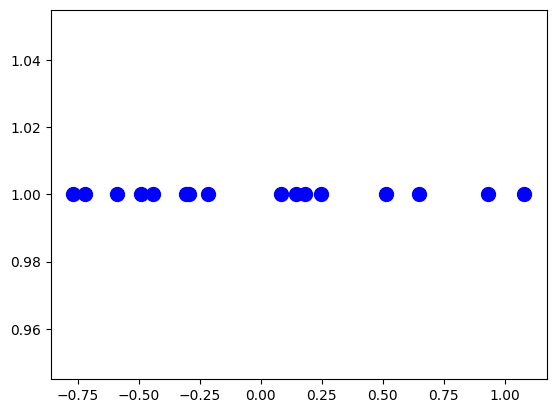

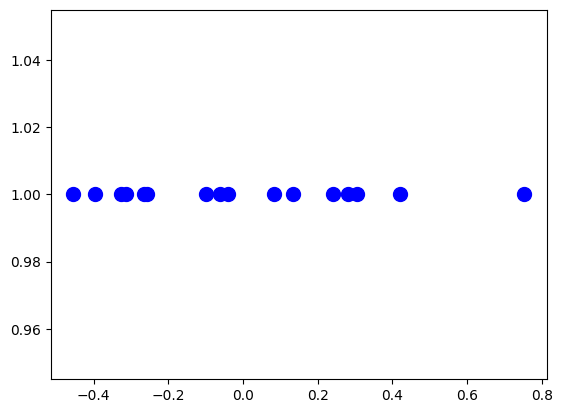

In [112]:
for i in range(3):
    dotplot(a_T715_r[i].flatten())

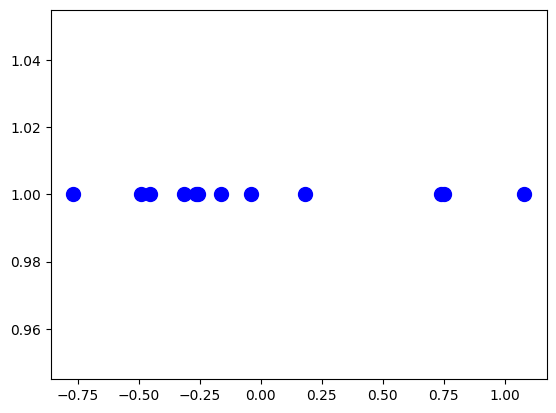

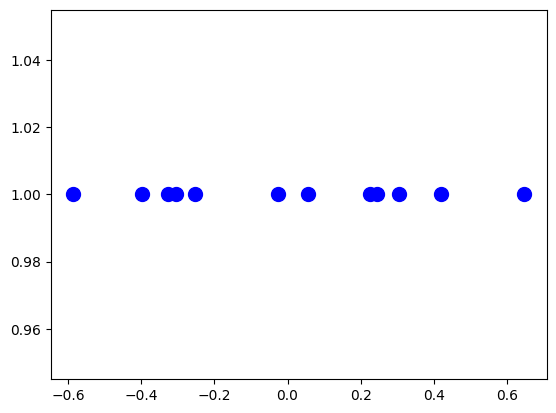

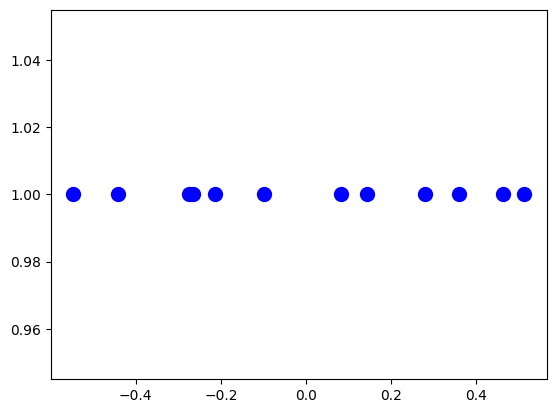

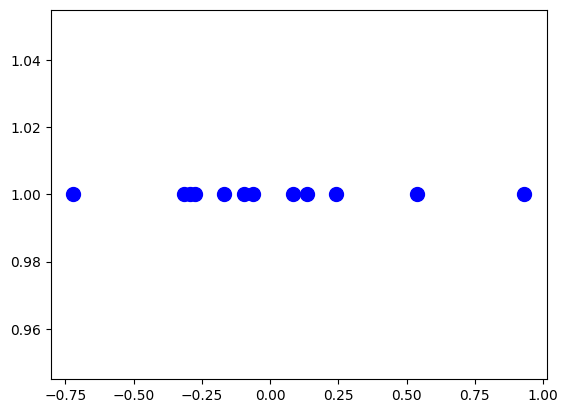

In [113]:
for i in range(4):
    dotplot(a_T715_r[:,i].flatten())

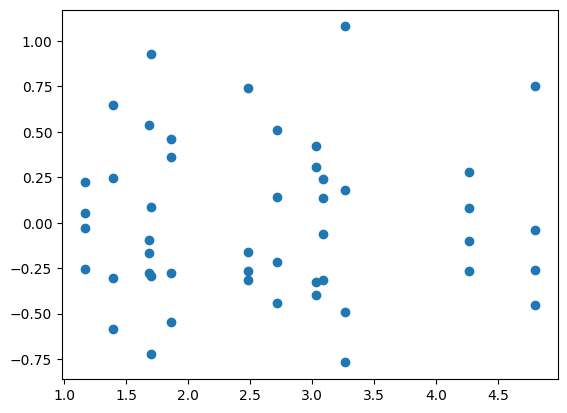

In [114]:
# plot y - y_pta vs y_pta
plt.scatter(a_T715_pta, a_T715 - a_T715_pta)

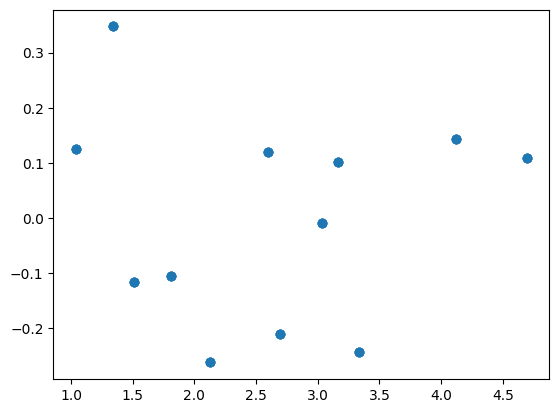

In [115]:
# plot y_pt - y_pt_hat vs y_pt_hat
plt.scatter(a_T715_pt_hat, a_T715_pta - a_T715_pt_hat)

In [116]:
# E 7.09
# find the scale of the reference distribution for comparing treatments
sigma708_t_hat = np.sqrt((SE708 / 36) / (3 * 4)) # 3 poisons * 4 animals
sigma709_t_hat = np.sqrt(se_T715 / (3 * 4))
sigma708_t_hat, sigma709_t_hat

(np.float64(0.04306003560921271), np.float64(0.14348972064656212))

In [117]:
(np.unique(a708pa).max() - np.unique(a708pa).min())/sigma708_t_hat, (np.unique(a_T715_pa).max() - np.unique(a_T715_pa).min())/sigma709_t_hat
# it is clear that the transformed data is more sensitive and easier to interpret

(np.float64(7.939496453339109), np.float64(13.924516724009655))

In [118]:
def find_residuals_sum_sqr(data):
    pa = np.tile(data.mean(axis=(1,2), keepdims=True), (1,4,4))
    ta = np.tile(data.mean(axis=(0,2), keepdims=True), (3,1,4))
    r = data - np.tile(data.mean(axis=2, keepdims=True), (1,1,4))
    return (r**2).sum()

In [ ]:
def transform_data(data, m):
    from scipy.stats import gmean
    g_mean = gmean(data)
    if m == 0:
        # print(m)
        return g_mean * np.log(data)
    
    return (data**m - 1) / (m * (g_mean**(m-1)))

In [120]:
m_sum_sqr = []
for m in np.linspace(-3, 3, 1201):
    data = transform_data(a708, m)
    sum_square = find_residuals_sum_sqr(data)
    m_sum_sqr.append([m, sum_square])
m_sum_sqr    

0.0


[[np.float64(-3.0), np.float64(2.503267227075758)],
 [np.float64(-2.995), np.float64(2.490149698667397)],
 [np.float64(-2.99), np.float64(2.4771092065106424)],
 [np.float64(-2.985), np.float64(2.4641452871601857)],
 [np.float64(-2.98), np.float64(2.451257480082619)],
 [np.float64(-2.975), np.float64(2.438445327637838)],
 [np.float64(-2.97), np.float64(2.425708375060567)],
 [np.float64(-2.965), np.float64(2.4130461704419965)],
 [np.float64(-2.96), np.float64(2.4004582647115593)],
 [np.float64(-2.955), np.float64(2.387944211618798)],
 [np.float64(-2.95), np.float64(2.375503567715378)],
 [np.float64(-2.945), np.float64(2.3631358923372052)],
 [np.float64(-2.94), np.float64(2.350840747586664)],
 [np.float64(-2.935), np.float64(2.33861769831497)],
 [np.float64(-2.93), np.float64(2.3264663121046403)],
 [np.float64(-2.925), np.float64(2.3143861592520754)],
 [np.float64(-2.92), np.float64(2.3023768127502677)],
 [np.float64(-2.915), np.float64(2.2904378482716012)],
 [np.float64(-2.91), np.float6

In [121]:
np.array(m_sum_sqr)[:,1].min()

np.float64(0.43001414511559133)

In [122]:
a708

array([[[0.31, 0.45, 0.46, 0.43],
        [0.82, 1.1 , 0.88, 0.72],
        [0.43, 0.45, 0.63, 0.76],
        [0.45, 0.71, 0.66, 0.63]],

       [[0.36, 0.29, 0.4 , 0.23],
        [0.92, 0.61, 0.49, 1.24],
        [0.44, 0.35, 0.31, 0.4 ],
        [0.56, 1.02, 0.71, 0.38]],

       [[0.22, 0.21, 0.18, 0.23],
        [0.3 , 0.37, 0.38, 0.29],
        [0.23, 0.25, 0.24, 0.22],
        [0.3 , 0.36, 0.31, 0.33]]])

In [123]:
stats.boxcox(a708.flatten())

(array([-1.45614593, -0.92484813, -0.89568073, -0.98591554, -0.20569753,
         0.09369664, -0.13081468, -0.34867757, -0.98591554, -0.92484813,
        -0.50260146, -0.28842374, -0.92484813, -0.36445569, -0.44813679,
        -0.50260146, -1.23438801, -1.55895802, -1.08513961, -1.93609202,
        -0.08464324, -0.54090997, -0.81310972,  0.20700825, -0.95491016,
        -1.27526009, -1.45614593, -1.08513961, -0.64463951,  0.01973234,
        -0.36445569, -1.15709347, -2.01207244, -2.09289841, -2.3705909 ,
        -1.93609202, -1.5063872 , -1.19503076, -1.15709347, -1.55895802,
        -1.93609202, -1.79680183, -1.86447421, -2.01207244, -1.5063872 ,
        -1.23438801, -1.45614593, -1.36197582]),
 np.float64(-0.3593134617758121))

In [124]:
# Q 7.6 to analyze the footwear data of Section 4.2 as randomized block design
a_Q76 = np.array([13.2,14.,8.2,8.8,10.9,11.2,14.3,14.2,10.7,11.8,6.6,6.4,9.5,9.8,10.8,11.3,8.8,9.3,13.3,13.6]).reshape(10,2)
a_Q76, 20

(array([[13.2, 14. ],
        [ 8.2,  8.8],
        [10.9, 11.2],
        [14.3, 14.2],
        [10.7, 11.8],
        [ 6.6,  6.4],
        [ 9.5,  9.8],
        [10.8, 11.3],
        [ 8.8,  9.3],
        [13.3, 13.6]]),
 20)

In [125]:
(np.diff(a_Q76,axis=1).mean() - 0) / np.sqrt(np.diff(a_Q76, axis=1).var(ddof=1)/10) # t score

np.float64(3.348876536221576)

In [126]:
stats.t.sf(3.3489, df=9)

np.float64(0.004269231098725953)

In [127]:
# block (boys) averages and deviations
a_Q76_b = np.tile(a_Q76.mean(axis=1, keepdims=True), (1,2))
a_Q76_bd = a_Q76_b - a_Q76.mean()
a_Q76_b, a_Q76_bd, 9 # freedom

(array([[13.6 , 13.6 ],
        [ 8.5 ,  8.5 ],
        [11.05, 11.05],
        [14.25, 14.25],
        [11.25, 11.25],
        [ 6.5 ,  6.5 ],
        [ 9.65,  9.65],
        [11.05, 11.05],
        [ 9.05,  9.05],
        [13.45, 13.45]]),
 array([[ 2.765,  2.765],
        [-2.335, -2.335],
        [ 0.215,  0.215],
        [ 3.415,  3.415],
        [ 0.415,  0.415],
        [-4.335, -4.335],
        [-1.185, -1.185],
        [ 0.215,  0.215],
        [-1.785, -1.785],
        [ 2.615,  2.615]]),
 9)

In [128]:
# treatment (materials) averages and deviations
a_Q76_m = np.tile(a_Q76.mean(axis=0, keepdims=True), (10,1))
a_Q76_md = a_Q76_m - a_Q76.mean()
a_Q76_m, a_Q76_md, 1 # freedom

(array([[10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04],
        [10.63, 11.04]]),
 array([[-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205],
        [-0.205,  0.205]]),
 1)

In [129]:
a_Q76_r = a_Q76 - a_Q76_b - a_Q76_m + a_Q76.mean()
a_Q76_r, 9

(array([[-0.195,  0.195],
        [-0.095,  0.095],
        [ 0.055, -0.055],
        [ 0.255, -0.255],
        [-0.345,  0.345],
        [ 0.305, -0.305],
        [ 0.055, -0.055],
        [-0.045,  0.045],
        [-0.045,  0.045],
        [ 0.055, -0.055]]),
 9)

In [130]:
# f score
(a_Q76_md ** 2).sum() / ((a_Q76_r ** 2).sum()/9), 3.3489 ** 2 # t score square

(np.float64(11.214974054855423), 11.21513121)

## Chapter 8

## Table 8.1
represent the data in table 8.1 with pandas dataframe
* 1 column for rows (driver)
* 1 column for columns in the table (car)
* 1 column for addtives (ABCD)
* the last column for the reading

In [131]:
np.indices((4,4)) # generate indices (row and col)

array([[[0, 0, 0, 0],
        [1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3]],

       [[0, 1, 2, 3],
        [0, 1, 2, 3],
        [0, 1, 2, 3],
        [0, 1, 2, 3]]])

In [132]:
df_T801 = pd.DataFrame({
    'rows': ['I'] *4 + ['II']*4 + ['III']*4 + ['IV']*4,
    'cols': np.indices((4,4))[1].flatten(),
    'treatment': [i for i in 'ABDCDCABBDCACABD'],
    'emission': [21,26,20,25,23,26,20,27,15,13,16,16,17,15,20,20]
})
df_T801

,rows,cols,treatment,emission
0,I,0,A,21
1,I,1,B,26
2,I,2,D,20
3,I,3,C,25
4,II,0,D,23
5,II,1,C,26
6,II,2,A,20
7,II,3,B,27
8,III,0,B,15
9,III,1,D,13


In [133]:
df_T801['grand average'] = df_T801['emission'].mean()
df_T801

,rows,cols,treatment,emission,grand average
0,I,0,A,21,20.0
1,I,1,B,26,20.0
2,I,2,D,20,20.0
3,I,3,C,25,20.0
4,II,0,D,23,20.0
5,II,1,C,26,20.0
6,II,2,A,20,20.0
7,II,3,B,27,20.0
8,III,0,B,15,20.0
9,III,1,D,13,20.0


In [134]:
df_T801['row deviations'] = df_T801.groupby('rows')['emission'].transform('mean')-df_T801['grand average']

In [135]:
df_T801['col deviations'] = df_T801.groupby('cols')['emission'].transform('mean') - df_T801['emission'].mean()

In [136]:
df_T801['treatment deviations'] = df_T801.groupby('treatment')['emission'].transform('mean') - df_T801['grand average']

In [137]:
df_T801['residuals'] = df_T801['emission'] - df_T801['grand average'] - df_T801['row deviations'] - df_T801['col deviations'] - df_T801['treatment deviations']

In [138]:
df_T801['predicted'] = df_T801['grand average'] + df_T801['row deviations'] + df_T801['col deviations'] + df_T801['treatment deviations']

In [139]:
df_T801

,rows,cols,treatment,emission,grand average,row deviations,col deviations,treatment deviations,residuals,predicted
0,I,0,A,21,20.0,3.0,-1.0,-2.0,1.0,20.0
1,I,1,B,26,20.0,3.0,0.0,2.0,1.0,25.0
2,I,2,D,20,20.0,3.0,-1.0,-1.0,-1.0,21.0
3,I,3,C,25,20.0,3.0,2.0,1.0,-1.0,26.0
4,II,0,D,23,20.0,4.0,-1.0,-1.0,1.0,22.0
5,II,1,C,26,20.0,4.0,0.0,1.0,1.0,25.0
6,II,2,A,20,20.0,4.0,-1.0,-2.0,-1.0,21.0
7,II,3,B,27,20.0,4.0,2.0,2.0,-1.0,28.0
8,III,0,B,15,20.0,-5.0,-1.0,2.0,-1.0,16.0
9,III,1,D,13,20.0,-5.0,0.0,-1.0,-1.0,14.0


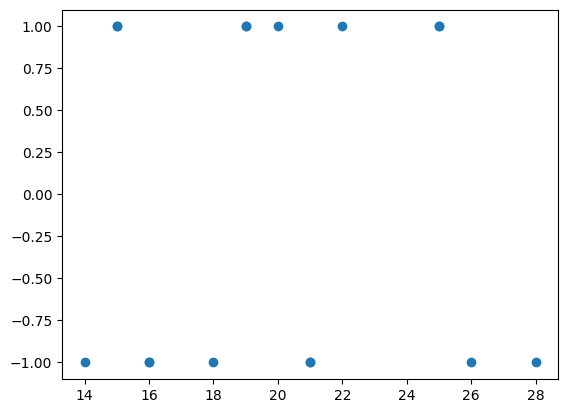

In [140]:
plt.scatter(df_T801['predicted'], df_T801['residuals']) # E 8.02

In [141]:
df_T801_ANOVA = (df_T801[df_T801.columns[-5:]] ** 2).sum().to_frame(name='sum of squares').reset_index(names=['source of variance'])

In [142]:
df_T801_ANOVA['degrees of freedom'] = [1,3,3,3,6]

In [143]:
df_T801_ANOVA['mean square'] = df_T801_ANOVA['sum of squares'] / df_T801_ANOVA['degrees of freedom']

In [144]:
df_T801_ANOVA

,source of variance,sum of squares,degrees of freedom,mean square
0,row deviations,216.0,1,216.000000
1,col deviations,24.0,3,8.000000
2,treatment deviations,40.0,3,13.333333
3,residuals,16.0,3,5.333333
4,predicted,6680.0,6,1113.333333


In [145]:
df_T801_ANOVA['ratio of mean squares'] = df_T801_ANOVA['mean square'] / df_T801_ANOVA[df_T801_ANOVA['source of variance']=='residuals']['mean square'].values

In [146]:
df_T801_ANOVA

,source of variance,sum of squares,degrees of freedom,mean square,ratio of mean squares
0,row deviations,216.0,1,216.000000,40.50
1,col deviations,24.0,3,8.000000,1.50
2,treatment deviations,40.0,3,13.333333,2.50
3,residuals,16.0,3,5.333333,1.00
4,predicted,6680.0,6,1113.333333,208.75


In [147]:
def get_f_sf(row, ref_row):
    return stats.f.sf(row['mean squares'].to_numpy(), dfn=row['degrees of freedom'].to_numpy(), dfd=ref_row['degrees of freedom'].to_numpy())


In [148]:
df_T801_ANOVA['sf'] = df_T801_ANOVA.apply(lambda row: stats.f.sf(row['ratio of mean squares'], dfn=row['degrees of freedom'], dfd=df_T801_ANOVA.loc[4,'degrees of freedom']), axis=1)

In [149]:
df_T801_ANOVA

,source of variance,sum of squares,degrees of freedom,mean square,ratio of mean squares,sf
0,row deviations,216.0,1,216.000000,40.50,0.000707
1,col deviations,24.0,3,8.000000,1.50,0.307174
2,treatment deviations,40.0,3,13.333333,2.50,0.156490
3,residuals,16.0,3,5.333333,1.00,0.454725
4,predicted,6680.0,6,1113.333333,208.75,0.000001


### Table 8.4

In [150]:
df_T804 = pd.DataFrame({
    'doff': np.repeat(np.arange(12)+1, 3),
    'spinneret_head': ['I', 'II', 'III'] * 12,
    'draw_ratio': [i for i in 'ABCBCACABBCAABCCABCABABCBCAABCBCACAB'],
    'strength': [19.56,23.16,29.72,
                 22.94,27.51,23.71,
                 25.06,17.7,22.32,
                 23.24,23.54,18.75,
                 16.28,22.29,28.09,
                 18.53,19.89,20.42,
                 23.98,20.46,19.28,
                 15.33,23.02,24.97,
                 24.41,22.44,19.23,
                 16.65,22.69,24.94,
                 18.96,24.19,21.95,
                 21.49,15.78,24.65]
})

In [151]:
df_T804.strength.sum()

np.float64(787.13)

In [152]:
df_T804['doff_deviations'] = df_T804.groupby('doff')['strength'].transform('mean') - df_T804['strength'].mean()

In [153]:
df_T804['spinneret_head_deviations'] = df_T804.groupby('spinneret_head')['strength'].transform('mean') - df_T804['strength'].mean()

In [154]:
df_T804['draw_ratio_deviations'] = df_T804.groupby('draw_ratio')['strength'].transform('mean') - df_T804['strength'].mean()

In [155]:
df_T804['grand_average'] = df_T804['strength'].mean()

In [156]:
df_T804['predicted'] = df_T804[['grand_average',	'doff_deviations', 'spinneret_head_deviations', 'draw_ratio_deviations']].sum(axis=1)

In [157]:
df_T804['residuals'] = df_T804['strength'] - df_T804['predicted']

In [158]:
df_T804

,doff,spinneret_head,draw_ratio,strength,doff_deviations,spinneret_head_deviations,draw_ratio_deviations,grand_average,predicted,residuals
0,1,I,A,19.56,2.281944,-1.328889,-3.090556,21.864722,19.727222,-0.167222
1,1,II,B,23.16,2.281944,0.024444,0.416944,21.864722,24.588056,-1.428056
2,1,III,C,29.72,2.281944,1.304444,2.673611,21.864722,28.124722,1.595278
3,2,I,B,22.94,2.855278,-1.328889,0.416944,21.864722,23.808056,-0.868056
4,2,II,C,27.51,2.855278,0.024444,2.673611,21.864722,27.418056,0.091944
5,2,III,A,23.71,2.855278,1.304444,-3.090556,21.864722,22.933889,0.776111
6,3,I,C,25.06,-0.171389,-1.328889,2.673611,21.864722,23.038056,2.021944
7,3,II,A,17.70,-0.171389,0.024444,-3.090556,21.864722,18.627222,-0.927222
8,3,III,B,22.32,-0.171389,1.304444,0.416944,21.864722,23.414722,-1.094722
9,4,I,B,23.24,-0.021389,-1.328889,0.416944,21.864722,20.931389,2.308611


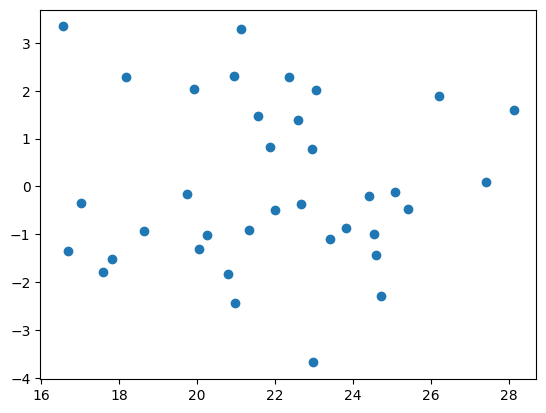

In [159]:
plt.scatter(df_T804.predicted, df_T804.residuals)

In [160]:
df_T804_ANOVA = (df_T804[['doff_deviations',	'spinneret_head_deviations', 'draw_ratio_deviations', 'residuals']] ** 2).sum().to_frame(name='sum_squares').reset_index(names=['variance_source'])

In [161]:
df_T804_ANOVA['degrees_of_freedom'] = [df_T804.groupby('doff').ngroups-1, df_T804.groupby('spinneret_head').ngroups-1, df_T804.groupby('draw_ratio').ngroups-1, 
                                       df_T804.shape[0] - np.sum((df_T804.groupby('doff').ngroups-1, df_T804.groupby('spinneret_head').ngroups-1, df_T804.groupby('draw_ratio').ngroups-1)) - 1 # 1 from the grand average
                                       ]

In [162]:
df_T804_ANOVA['mean_square'] = df_T804_ANOVA['sum_squares'] / df_T804_ANOVA.degrees_of_freedom

In [163]:
df_T804_ANOVA['ratio_of_mean_squares'] = df_T804_ANOVA.mean_square / df_T804_ANOVA[df_T804_ANOVA['variance_source']=='residuals']['mean_square'].to_numpy()

In [164]:
df_T804_ANOVA

,variance_source,sum_squares,degrees_of_freedom,mean_square,ratio_of_mean_squares
0,doff_deviations,63.884431,11,5.807676,1.125538
1,spinneret_head_deviations,41.617422,2,20.808711,4.032767
2,draw_ratio_deviations,202.482872,2,101.241436,19.620781
3,residuals,103.198172,20,5.159909,1.000000


In [165]:
df_T804_ANOVA['sf'] = df_T804_ANOVA.apply(lambda row: stats.f.sf(row['ratio_of_mean_squares'], dfn=row['degrees_of_freedom'], dfd=df_T804_ANOVA.loc[3,'degrees_of_freedom']), axis=1)

In [166]:
df_T804_ANOVA['t_scale'] = np.sqrt(df_T804_ANOVA.loc[3, 'ratio_of_mean_squares'] / np.array([12,3,3,36])) # E 8.03

In [167]:
df_T804_ANOVA

,variance_source,sum_squares,degrees_of_freedom,mean_square,ratio_of_mean_squares,sf,t_scale
0,doff_deviations,63.884431,11,5.807676,1.125538,0.392766,0.288675
1,spinneret_head_deviations,41.617422,2,20.808711,4.032767,0.033773,0.577350
2,draw_ratio_deviations,202.482872,2,101.241436,19.620781,0.000019,0.577350
3,residuals,103.198172,20,5.159909,1.000000,0.500000,0.166667


In [168]:
# E 8.03
pdf_E803 = [stats.t.pdf(np.linspace(-5,5,1001), df_T804_ANOVA.degrees_of_freedom[i], scale=df_T804_ANOVA.t_scale[i]) for i in range(4)]

In [169]:
df_T804.columns

Index(['doff', 'spinneret_head', 'draw_ratio', 'strength', 'doff_deviations',
       'spinneret_head_deviations', 'draw_ratio_deviations', 'grand_average',
       'predicted', 'residuals'],
      dtype='object')

In [196]:
stats.t.sf(df_T804.groupby('doff')['doff_deviations'].mean(), df=11, scale=0.288675)

array([3.65879224e-06, 4.12397235e-07, 7.17642016e-01, 5.28866824e-01,
       1.22047862e-01, 9.99995844e-01, 9.73338963e-01, 9.88212185e-01,
       2.93024398e-01, 9.21325147e-01, 7.10134875e-01, 9.99308549e-01])

5
2


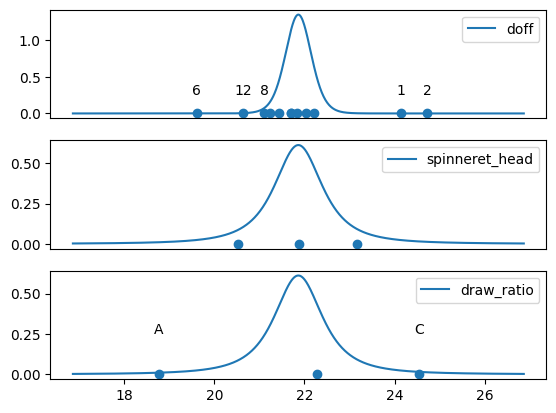

In [225]:
fig,ax = plt.subplots(3,1)
for i in range(3):
    if i!= 2:
        ax[i].set_xticks([])
    ax[i].plot(np.linspace(-5,5,1001)+df_T804['strength'].mean(), pdf_E803[i], label=df_T804_ANOVA.loc[i,'variance_source'][:-11])
    scatter_T804_x = df_T804.groupby(df_T804.columns[i])['strength'].mean()
    ax[i].scatter(scatter_T804_x,np.zeros(scatter_T804_x.shape[0]))
    scatter_T804_sf = stats.t.sf(scatter_T804_x, df=df_T804_ANOVA.loc[i,'degrees_of_freedom'], loc=df_T804['strength'].mean(), scale=df_T804_ANOVA.loc[i,'t_scale'])
    mask_T804 = (scatter_T804_sf > 0.975) | (scatter_T804_sf < 0.025)
    if mask_T804.sum()>0:
        print(mask_T804.sum())
        for j in range(mask_T804.sum()):
            ax[i].text(scatter_T804_x[mask_T804].values[j], 0.25, scatter_T804_x.index.values[mask_T804][j], ha='center')
    # # ax[i].set_title(df_T804_ANOVA.loc[i,'variance_source'][:-11])
    ax[i].legend()


### Appendix 8B Case 3

In [296]:
df_T8B3 = df_T804.copy()

In [297]:
df_T8B3['spinneret_head'] = np.array([np.tile(np.arange(3)+1,3) + 3*i for i in range(4)]).flatten()
df_T8B3['replicate'] = np.repeat(np.arange(4)+1, 9)

In [298]:
df_T8B3

,doff,spinneret_head,draw_ratio,strength,doff_deviations,spinneret_head_deviations,draw_ratio_deviations,grand_average,predicted,residuals,replicate
0,1,1,A,19.56,2.281944,-1.328889,-3.090556,21.864722,19.727222,-0.167222,1
1,1,2,B,23.16,2.281944,0.024444,0.416944,21.864722,24.588056,-1.428056,1
2,1,3,C,29.72,2.281944,1.304444,2.673611,21.864722,28.124722,1.595278,1
3,2,1,B,22.94,2.855278,-1.328889,0.416944,21.864722,23.808056,-0.868056,1
4,2,2,C,27.51,2.855278,0.024444,2.673611,21.864722,27.418056,0.091944,1
5,2,3,A,23.71,2.855278,1.304444,-3.090556,21.864722,22.933889,0.776111,1
6,3,1,C,25.06,-0.171389,-1.328889,2.673611,21.864722,23.038056,2.021944,1
7,3,2,A,17.70,-0.171389,0.024444,-3.090556,21.864722,18.627222,-0.927222,1
8,3,3,B,22.32,-0.171389,1.304444,0.416944,21.864722,23.414722,-1.094722,1
9,4,4,B,23.24,-0.021389,-1.328889,0.416944,21.864722,20.931389,2.308611,2


In [302]:
df_T8B3['replicate_deviations'] = df_T8B3.groupby('replicate')['strength'].transform('mean') - df_T8B3['grand_average']
df_T8B3['doff_deviations'] = df_T8B3.groupby('doff')['strength'].transform('mean') - df_T8B3['grand_average'] - df_T8B3['replicate_deviations']
df_T8B3['spinneret_head_deviations'] = df_T8B3.groupby('spinneret_head')['strength'].transform('mean') - df_T8B3['grand_average'] - df_T8B3['replicate_deviations']
df_T8B3['draw_ratio_deviations'] = df_T8B3.groupby('draw_ratio')['strength'].transform('mean') - df_T8B3['grand_average']
df_T8B3['predicted'] = df_T8B3[['grand_average', 'doff_deviations', 'spinneret_head_deviations', 'draw_ratio_deviations', 'replicate_deviations']].sum(axis=1)
df_T8B3['residuals'] = df_T8B3['strength'] - df_T8B3['predicted']

In [303]:
df_T8B3_ANOVA = (df_T8B3[[i for i in df_T8B3.columns if 'deviation' in i or 'residual' in i]]**2).sum().to_frame(name='sum_squares').reset_index(names=['variance_source'])

In [304]:
df_T8B3_ANOVA

,variance_source,sum_squares
0,doff_deviations,30.717933
1,spinneret_head_deviations,66.372667
2,draw_ratio_deviations,202.482872
3,residuals,78.442928
4,replicate_deviations,33.166497


### Appendix 8D

#### Table 8.12

In [45]:
df_T812 = pd.DataFrame({
    'block': np.repeat(np.arange(7)+1,7),
    'treatment': np.tile([i for i in 'ABCDEFG'],7),
    'wearing': [0,627,0,248,0,563,252,
                344,0,233,0,0,442,226,
                0,0,251,211,160,0,297,
                337,537,0,0,195,0,300,
                0,520,278,0,199,595,0,
                369,0,0,196,185,606,0,
                396,602,240,273,0,0,0]
})

In [46]:
df_T812 = df_T812.replace(0, np.nan)

In [5]:
df_T812['grand_average'] = df_T812['wearing'].mean()

In [6]:
not_na_mask_T812 = df_T812['wearing'].notna()

In [49]:
df_T812['block_deviation'] = df_T812[not_na_mask_T812].groupby('block')['wearing'].transform('mean') - df_T812.wearing.mean()

In [50]:
df_T812.head()

,block,treatment,wearing,grand_average,block_deviation
0,1,A,NaN,345.785714,NaN
1,1,B,627.0,345.785714,76.714286
2,1,C,NaN,345.785714,NaN
3,1,D,248.0,345.785714,76.714286
4,1,E,NaN,345.785714,NaN


In [51]:
# sum of squares for blocks
SB_T812 = (df_T812['block_deviation']**2).sum()
SB_T812

np.float64(97394.71428571429)

In [ ]:
# For each treatment, find all the blocks containing this treatment.
# sum the wearing of each treatment minus the corresponding block deviations sums (including all blocks where the treatment is in) and the sum grand average for each treatment group
# the result above gives the effect of one treatment vs the other treatment
# each pair of treatment in the same block happens twice. so divide it by 2
# then times by 4/7 to adjust the treatment effect as each block contains all 7 treatments
df_T812['treatment_deviation'] = (df_T812[not_na_mask_T812].groupby('treatment')['wearing'].transform('sum') - (df_T812[not_na_mask_T812].groupby('treatment')['block_deviation'].transform('sum') + df_T812[not_na_mask_T812].groupby('treatment')['grand_average'].transform('sum')))/2/7*4

In [73]:
df_T812['treatment_deviation'] = df_T812[not_na_mask_T812].groupby('treatment')['wearing'].transform('mean') - (df_T812[not_na_mask_T812].groupby('treatment')['block_deviation'].transform('mean') + df_T812[not_na_mask_T812].groupby('treatment')['grand_average'].transform('mean'))

In [82]:
df_T812['adjusted_treatment_deviation'] = df_T812.groupby('treatment')['treatment_deviation'].transform('mean') 
# replace the treatment deviation with the adjusted treatment deviation. Note here the nan values are also replaced

In [86]:
ST_T812 = (df_T812.adjusted_treatment_deviation**2).sum() / 2 # sum of squares for treatment. why devided by 2? maybe because again each pair of treatments appears 2 times the same block
ST_T812

np.float64(506798.5714285714)

In [87]:
df_T812.head()

,block,treatment,wearing,grand_average,block_deviation,treatment_deviation,adjusted_treatment_deviation
0,1,A,NaN,345.785714,NaN,NaN,21.642857
1,1,B,627.0,345.785714,76.714286,213.0,213.000000
2,1,C,NaN,345.785714,NaN,NaN,-89.928571
3,1,D,248.0,345.785714,76.714286,-126.0,-126.000000
4,1,E,NaN,345.785714,NaN,NaN,-162.857143


In [91]:
SA_T812 = (df_T812[not_na_mask_T812].grand_average**2).sum() # grand average sum of squares. only the ones with actual wearing values

In [103]:
SR_T812 = (df_T812['wearing']**2).sum() - SB_T812 - ST_T812 - SA_T812
SR_T812

np.float64(22071.428571430035)

In [104]:
# mean of square for F test
sb2_T812 = SB_T812 / 6 # 6 degrees of freedom
st2_T812 = ST_T812 / 6 # 6 degrees of freedom
sr2_T812 = SR_T812 / (28 - 1 - 6 - 6) # total 28 degrees of freedom, minus grand average degree of freedom and block and treatment

sb2_T812, st2_T812, sr2_T812

(np.float64(16232.452380952382),
 np.float64(84466.42857142857),
 np.float64(1471.428571428669))

In [105]:
# treatment t6 distribution scale = np.sqrt(k * sr2_T812 / lambda / total treatment)
np.sqrt(4 * sr2_T812 / 2 / 7)

np.float64(20.50385727772543)

### Table 8D.5
analysis of variance table for a Youden square

In [164]:
df_T8D5 = pd.DataFrame({
    'block': np.repeat(np.arange(7)+1,7),
    'treatment': np.tile([i for i in 'ABCDEFG'],7),
    'position': [0,'a',0,'b',0,'c','d',
                'a',0,'b',0,0,'d','c',
                0,0,'a','c','d',0,'b',
                'b','d',0,0,'c',0,'a',
                0,'c','d',0,'b','a',0,
                'c',0,0,'d','a','b',0,
                'd','b','c','a',0,0,0],
    'wearing': [0,627,0,248,0,563,252,
                344,0,233,0,0,442,226,
                0,0,251,211,160,0,297,
                337,537,0,0,195,0,300,
                0,520,278,0,199,595,0,
                369,0,0,196,185,606,0,
                396,602,240,273,0,0,0],
})

In [165]:
df_T8D5 = df_T8D5.replace(0, np.nan)

In [166]:
df_T8D5['grand_average'] = df_T8D5.wearing.mean()

In [167]:
df_T8D5['block_deviation'] = df_T8D5[not_na_mask_T812].groupby('block')['wearing'].transform('mean') - df_T8D5.wearing.mean()
df_T8D5['position_deviation'] = df_T8D5[not_na_mask_T812].groupby('position')['wearing'].transform('mean') - df_T8D5.wearing.mean()

In [168]:
df_T8D5['treatment_deviation'] = df_T8D5.apply(lambda row: row['wearing'] - row['block_deviation'] - row['grand_average'], axis=1)

In [169]:
df_T8D5['adjusted_treatment_deviation'] = df_T8D5.groupby('treatment')['treatment_deviation'].transform('mean') / (7*2) * 16 # 

In [170]:
df_T8D5_ANOVA = (df_T8D5[['wearing', 'grand_average', 'block_deviation', 'position_deviation', 'adjusted_treatment_deviation']]**2).sum().to_frame(name='sum_squares') # sum of squares
# Make some corrections
df_T8D5_ANOVA.index = ['total'] + df_T8D5_ANOVA.index[1:].to_list()
df_T8D5_ANOVA.loc['grand_average', 'sum_squares'] = df_T8D5_ANOVA.loc['grand_average', 'sum_squares'] * 28 / 49
df_T8D5_ANOVA.loc['adjusted_treatment_deviation', 'sum_squares'] = df_T8D5_ANOVA.loc['adjusted_treatment_deviation', 'sum_squares'] / 2
df_T8D5_ANOVA.loc['residual', 'sum_squares'] = df_T8D5_ANOVA.loc['total', 'sum_squares'] - df_T8D5_ANOVA.loc['grand_average', 'sum_squares'] - df_T8D5_ANOVA.loc['block_deviation', 'sum_squares'] - df_T8D5_ANOVA.loc['position_deviation', 'sum_squares'] - df_T8D5_ANOVA.loc['adjusted_treatment_deviation', 'sum_squares']
df_T8D5_ANOVA

,sum_squares
total,3.974162e+06
grand_average,3.347897e+06
block_deviation,9.739471e+04
position_deviation,9.846429e+03
adjusted_treatment_deviation,5.067986e+05
residual,1.222500e+04


In [172]:
df_T8D5_ANOVA['dof'] = [28,1,6,3,6,12]
df_T8D5_ANOVA['mean_square'] = df_T8D5_ANOVA['sum_squares'] / df_T8D5_ANOVA['dof']
df_T8D5_ANOVA['ratio_mean_square'] = df_T8D5_ANOVA['mean_square']/df_T8D5_ANOVA.loc['residual', 'mean_square']
df_T8D5_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
total,3.974162e+06,28,1.419344e+05,139.322068
grand_average,3.347897e+06,1,3.347897e+06,3286.279544
block_deviation,9.739471e+04,6,1.623245e+04,15.933696
position_deviation,9.846429e+03,3,3.282143e+03,3.221735
adjusted_treatment_deviation,5.067986e+05,6,8.446643e+04,82.911832
residual,1.222500e+04,12,1.018750e+03,1.000000


In [175]:
stats.f.sf(82.9, dfn=6, dfd=12)

np.float64(4.5938607435319786e-09)